<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_2_2_%D0%9B%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B7_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Набір даних включає наступні атрибути:

ID: Унікальний ідентифікатор рядка

Customer ID: Унікальний ідентифікатор для кожного клієнта (це поле містить дублікати для різної інформації клієнтів, тому його просто видаляємо)

Surname: Прізвище клієнта

Credit Score: Числове значення, що представляє кредитний рейтинг клієнта

Geography: Країна, де проживає клієнт (Франція, Іспанія або Німеччина)

Gender: Стать клієнта (Чоловік або Жінка)

Age: Вік клієнта

Tenure: Кількість років, які клієнт обслуговується в банку

Balance: Баланс рахунку клієнта

NumOfProducts: Кількість банківських продуктів, які використовує клієнт (наприклад, ощадний рахунок, кредитна картка)

HasCrCard: Чи має клієнт кредитну картку (1 = так, 0 = ні)

IsActiveMember: Чи є клієнт активним членом (1 = так, 0 = ні)

EstimatedSalary: Оціночна зарплата клієнта

Exited: Чи залишив клієнт банк (1 = так, 0 = ні)

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [82]:
!pip install opendatasets --upgrade --quiet
!pip install pyarrow --quiet

In [83]:
import opendatasets as od
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.dummy import DummyClassifier
import joblib

In [84]:
od.version()

'0.1.22'

In [85]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4/data'

In [86]:
od.download(dataset_url)

Skipping, found downloaded files in "./bank-customer-churn-prediction-dlu-course-c-4" (use force=True to force download)


In [87]:
raw_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/train.csv')

In [88]:

raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [89]:
X = raw_df.drop('Exited', axis=1)
y = raw_df['Exited']

In [90]:
train_df, val_df= train_test_split(raw_df, test_size=0.2, random_state=42, stratify = y)

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [91]:
input_cols = list(raw_df.columns)[1:-1]
target_col = 'Exited'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [92]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [93]:
numeric_cols, categorical_cols

(['CustomerId',
  'CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Surname', 'Geography', 'Gender'])

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [94]:
train_inputs[numeric_cols].describe().round(2)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,15690923.99,658.84,37.69,5.03,43008.17,1.59,0.79,0.49,117992.40
std,146930.97,72.33,8.14,2.78,59906.63,0.53,0.41,0.50,45589.48
min,1581102.00,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,15635116.00,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83343.73
50%,15689953.00,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123613.91
75%,15756921.50,708.00,42.00,7.00,109949.05,2.00,1.00,1.00,156912.81
max,15815690.00,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


In [95]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       12000 non-null  float64
 1   Surname          12000 non-null  object 
 2   CreditScore      12000 non-null  float64
 3   Geography        12000 non-null  object 
 4   Gender           12000 non-null  object 
 5   Age              12000 non-null  float64
 6   Tenure           12000 non-null  float64
 7   Balance          12000 non-null  float64
 8   NumOfProducts    12000 non-null  float64
 9   HasCrCard        12000 non-null  float64
 10  IsActiveMember   12000 non-null  float64
 11  EstimatedSalary  12000 non-null  float64
dtypes: float64(9), object(3)
memory usage: 1.2+ MB


#preprocessing

1. Спостереження при огляді даних:
 Пропущенних значень немає, тому їх не треба заповнювати, дані мають адекватні значення
2. Видалити колонки ID, Customer ID та Surname за датасету перед подання в модель, тому що вони не є значущими
3. Закодувати категоріальні колонки Geography та Gender
4. зробити scaling числовим колонкам



In [96]:
#Видалимо колонки ID, Customer ID та Surname
train_inputs_preprocessed = train_inputs.drop(['CustomerId', 'Surname'], axis=1)
val_inputs_preprocessed= val_inputs.drop(['CustomerId', 'Surname'], axis=1)

numeric_cols_preprocessed = train_inputs_preprocessed.select_dtypes(include=np.number).columns.tolist()


In [97]:
#Масштабування колонок
scaler = MinMaxScaler()

In [98]:
scaler.fit(train_inputs_preprocessed[numeric_cols_preprocessed])

MinMaxScaler()

In [99]:
train_inputs_preprocessed[numeric_cols_preprocessed] = scaler.transform(train_inputs_preprocessed[numeric_cols_preprocessed])
val_inputs_preprocessed[numeric_cols_preprocessed] = scaler.transform(val_inputs_preprocessed[numeric_cols_preprocessed])

In [100]:
val_inputs_preprocessed

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420
...,...,...,...,...,...,...,...,...,...,...
10550,0.589499,France,Male,0.357143,0.4,0.000000,0.333333,1.0,0.0,0.667682
8866,0.768496,France,Male,0.642857,0.6,0.000000,0.000000,1.0,0.0,0.885353
3244,0.589499,Spain,Male,0.250000,0.5,0.000000,0.333333,1.0,0.0,0.883589
12441,0.699284,Spain,Male,0.267857,0.5,0.658646,0.000000,1.0,0.0,0.528593


In [101]:
#кодування категоріальних ознак
#Gender

train_inputs_preprocessed['Gender'] = train_inputs_preprocessed['Gender'].map({'Female': 0, 'Male': 1})

val_inputs_preprocessed['Gender'] = val_inputs_preprocessed['Gender'].map({'Female': 0, 'Male': 1})



In [102]:
categorical_cols_preprossesed = train_inputs_preprocessed.select_dtypes('object').columns.tolist()

In [103]:
categorical_cols_preprossesed

['Geography']

In [104]:
#Counrty
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [105]:
encoder.fit(train_inputs_preprocessed[['Geography']])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [106]:
encoder.categories_


[array(['France', 'Germany', 'Spain'], dtype=object)]

In [107]:
encoded_cols = list(encoder.categories_[0])


In [108]:
encoded_cols

['France', 'Germany', 'Spain']

In [109]:
train_inputs_preprocessed[encoded_cols] = encoder.transform(train_inputs_preprocessed[['Geography']])
val_inputs_preprocessed[encoded_cols] = encoder.transform(val_inputs_preprocessed[['Geography']])

In [110]:
train_inputs_preprocessed = train_inputs_preprocessed.drop(['Geography'], axis=1)
val_inputs_preprocessed = val_inputs_preprocessed.drop(['Geography'], axis=1)

In [111]:
train_inputs_preprocessed

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain
7180,0.599045,1,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0
10393,0.603819,0,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0
80,0.653938,1,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0
3365,0.568019,1,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0
12236,0.658711,1,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,0,0.267857,0.4,0.000000,0.333333,0.0,0.0,0.617686,1.0,0.0,0.0
8463,0.577566,0,0.392857,0.1,0.000000,0.000000,1.0,1.0,0.239129,1.0,0.0,0.0
8143,0.453461,1,0.196429,0.8,0.000000,0.333333,1.0,1.0,0.667682,1.0,0.0,0.0
11512,0.379475,1,0.428571,0.7,0.000000,0.333333,0.0,0.0,0.363197,0.0,0.0,1.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [112]:
train_inputs_preprocessed.to_parquet('train_inputs_preprocessed.parquet')
val_inputs_preprocessed.to_parquet('val_inputs_preprocessed.parquet')

train_targets.to_frame().to_parquet('train_targets.parquet')
val_targets.to_frame().to_parquet('val_targets.parquet')

In [113]:
!ls


bank-customer-churn-prediction-dlu-course-c-4
log_reg.joblib
sample_data
submission_log_reg.csv
train_inputs_preprocessed.parquet
train_targets.parquet
val_inputs_preprocessed.parquet
val_targets.parquet


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [114]:
model = LogisticRegression(solver='liblinear')

In [115]:
train_inputs_preprocessed

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain
7180,0.599045,1,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0
10393,0.603819,0,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0
80,0.653938,1,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0
3365,0.568019,1,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0
12236,0.658711,1,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,0,0.267857,0.4,0.000000,0.333333,0.0,0.0,0.617686,1.0,0.0,0.0
8463,0.577566,0,0.392857,0.1,0.000000,0.000000,1.0,1.0,0.239129,1.0,0.0,0.0
8143,0.453461,1,0.196429,0.8,0.000000,0.333333,1.0,1.0,0.667682,1.0,0.0,0.0
11512,0.379475,1,0.428571,0.7,0.000000,0.333333,0.0,0.0,0.363197,0.0,0.0,1.0


In [116]:
train_targets

,Exited
7180,0.0
10393,0.0
80,0.0
3365,0.0
12236,0.0
...,...
9493,0.0
8463,0.0
8143,0.0
11512,0.0


In [117]:
train_inputs_preprocessed

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain
7180,0.599045,1,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0
10393,0.603819,0,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0
80,0.653938,1,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0
3365,0.568019,1,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0
12236,0.658711,1,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,0,0.267857,0.4,0.000000,0.333333,0.0,0.0,0.617686,1.0,0.0,0.0
8463,0.577566,0,0.392857,0.1,0.000000,0.000000,1.0,1.0,0.239129,1.0,0.0,0.0
8143,0.453461,1,0.196429,0.8,0.000000,0.333333,1.0,1.0,0.667682,1.0,0.0,0.0
11512,0.379475,1,0.428571,0.7,0.000000,0.333333,0.0,0.0,0.363197,0.0,0.0,1.0


In [118]:
model.fit(train_inputs_preprocessed, train_targets)



LogisticRegression(solver='liblinear')

In [119]:
model.coef_.round(2)

array([[-0.88, -0.86,  8.45, -0.08, -1.1 , -3.94, -0.19, -1.25,  0.19,
        -1.03,  0.54, -1.12]])

In [120]:
print(model.intercept_)

[-1.60464126]


7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [121]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.42%


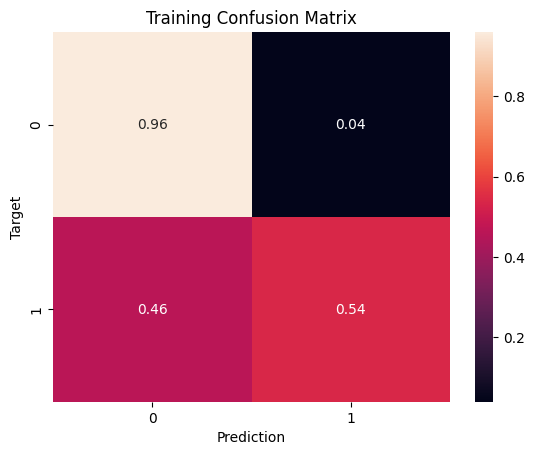

In [122]:
train_preds = predict_and_plot(train_inputs_preprocessed, train_targets, name = "Training")

Accuracy: 87.17%


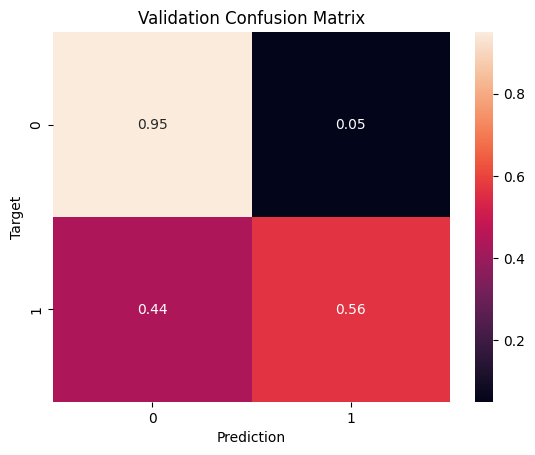

In [123]:
val_preds = predict_and_plot(val_inputs_preprocessed, val_targets, name = "Validation")

In [124]:
#F1 score
f1_score(train_targets, train_preds, pos_label= 1)

0.6352429296591733

In [125]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds, pos_label=1)
  print(f"F1 score {name}: {f1_score_:.2f}%")

get_f1_score(train_inputs_preprocessed, train_targets, 'Training')
get_f1_score(val_inputs_preprocessed, val_targets, 'Validation')

F1 score Training: 0.64%
F1 score Validation: 0.64%


In [126]:
#ROC curve
def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.88


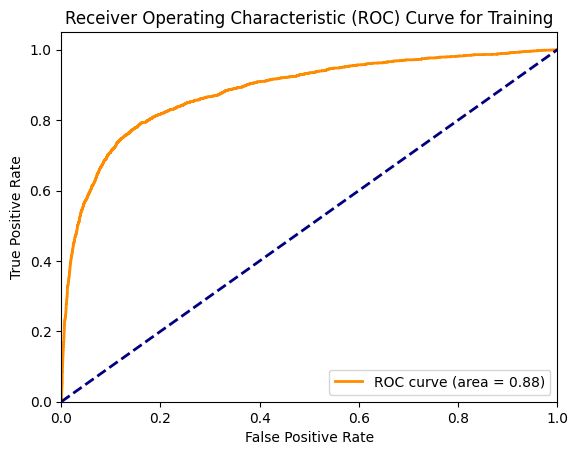

AUROC for Validation: 0.88


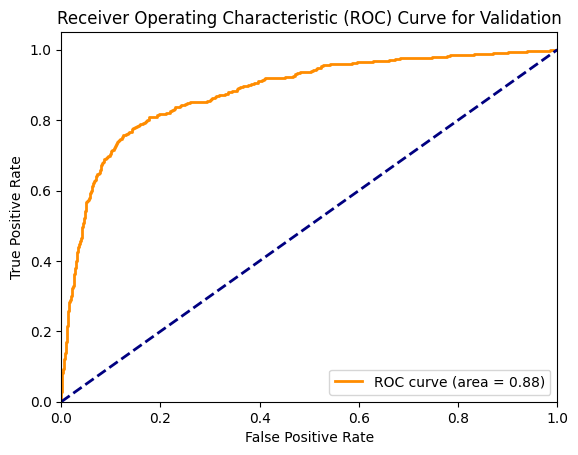

In [127]:
compute_auroc_and_build_roc(train_inputs_preprocessed, train_targets, 'Training')
compute_auroc_and_build_roc(val_inputs_preprocessed, val_targets, 'Validation')

#Висновок
Напевно, як для першої (базової) реалізації точність моделіи задовільна.
Accuracy , f1 score та auroc на тестовому і валідаційному наборі майже однакові. Отже модель більш менш стабільно передбачає на нових даних.
Проте, згідно Confusion matrix, модель пропускає більше 50 % людей, які потім все ж припинили обслуговування в банку. Це може бути проблемою, адже мета якраз виявити цих людей.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [128]:
dummy_model = DummyClassifier(strategy='most_frequent')

In [129]:
dummy_model.fit(train_inputs_preprocessed, train_targets)

DummyClassifier(strategy='most_frequent')

In [130]:
dummy_train_preds = dummy_model.predict(train_inputs_preprocessed)
dummy_val_preds = dummy_model.predict(val_inputs_preprocessed)



In [131]:
accuracy_dummy_train = accuracy_score(train_targets, dummy_train_preds)
accuracy_dummy_val = accuracy_score(val_targets, dummy_val_preds)
print(f'Train dataset accuracy: {accuracy_dummy_train:.2f}')
print(f'Validation dataset accuracy: {accuracy_dummy_val:.2f}')

Train dataset accuracy: 0.80
Validation dataset accuracy: 0.80


#Висновок
Модель розроблена мною дає на приблизно на 7.5 % більшу точність ніж модель, яка передбачає найбльш поширенні значення в датасеті.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [132]:
#створимо словник для всіх об"єктів
bank_escaper = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': (list(train_inputs_preprocessed.columns)),
    'target_col': target_col,
    'numeric_cols': numeric_cols_preprocessed,
    'categorical_cols': categorical_cols_preprossesed,
    'encoded_cols': encoded_cols
}

In [133]:
joblib.dump(bank_escaper, 'log_reg.joblib')

['log_reg.joblib']

In [134]:
log_reg2 = joblib.load('log_reg.joblib')

In [135]:
test_pred2 = log_reg2['model'].predict(val_inputs_preprocessed)
accuracy_score(val_targets, test_pred2)

0.8716666666666667

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [136]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, encoded_cols, input_df: pd.DataFrame):
    input_df = input_df.copy()
    input_df = input_df.drop(['id','CustomerId', 'Surname'], axis=1, errors='ignore')
    input_df['Gender'] = input_df['Gender'].map({'Female': 0, 'Male': 1})
    input_df[encoded_cols] = encoder.transform(input_df[['Geography']])
    input_df = input_df.drop(['Geography'], axis=1)
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    prob = model.predict_proba(input_df)[:, 1]
    return prob

In [137]:
predict_raw_df(scaler, encoder, numeric_cols_preprocessed, categorical_cols_preprossesed, encoded_cols, val_inputs[:5])

array([0.01455809, 0.04233578, 0.06223693, 0.20434757, 0.05590963])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [138]:
test_raw_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/test.csv')

In [139]:
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09


In [140]:
exited_on_test_raw = predict_raw_df(scaler, encoder, numeric_cols_preprocessed, categorical_cols_preprossesed, encoded_cols, test_raw_df)

In [141]:
exited_on_test_raw.shape

(10000,)

12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [142]:
sample_submission_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/sample_submission.csv')

In [143]:
test_raw_df['Exited'] = exited_on_test_raw

sample_submission_df['Exited'] = sample_submission_df['id'].map(
    test_raw_df.set_index('id')['Exited']
)

sample_submission_df.head(5)
sample_submission_df.to_csv('submission_log_reg.csv', index=False)

In [144]:
sample_submission_df.head(5)

,id,Exited
0,15000,0.075341
1,15001,0.035385
2,15002,0.152962
3,15003,0.194683
4,15004,0.055614
